# Практическая работа №1

## Метод k ближайших соседей


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("survey.csv")
data.head()

,Отметка времени,"Как вы себя чувствуете, когда оказались в центре внимания в малознакомой компании?",Как чаще всего принимаются ваши повседневные решения о покупках?,"Покупая сложную технику или мебель, какой подход вам ближе?",Что вы выберете при покупке повседневной вещи?,Быстро ли твой телефон разряжается?,Ты часто снимаешь на телефон фото/видео?,"При выборе предмета интерьера или одежды, что станет решающим фактором?",Часто ли твой телефон тормозит/лагает?,"Тебе важно, чтобы все приложения со временем работали одинаково?",Любите ли вы путешествовать?,"Как часто ты меняешь смартфон на новый? Введите число лет (целое, например: 2)","Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)",Часто ли вы публикуете фотографии или видео в социальных сетях?,Часто ли вы смотрите фильмы и сериалы на телефоне?,"Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)","Ближайшая станция метро? (Точное название, например: Преображенская площадь, Сокольники и т.п.)",У тебя айфон или андроид?
0,11.09.2026 20:01:26,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Дизайн, эстетика",Нет,Да,Да,4,5,Нет,Да,Зеленый,Юго-западная,Айфон
1,11.09.2026 20:01:27,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Да,"Долговечность, польза",Нет,Да,Да,3,1,Да,Да,Карий,Бульвар Дмитрия Донского,Айфон
2,11.09.2026 20:01:38,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Нет,Да,"Дизайн, эстетика",Нет,Да,Да,3,1,Нет,Нет,Карий,Братиславская,Айфон
3,11.09.2026 20:01:41,Дискомфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Долговечность, польза",Нет,Да,Да,3,0,Нет,Нет,Серый,Авиамоторная,Айфон
4,11.09.2026 20:02:11,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Да,Нет,"Долговечность, польза",Да,Да,Да,4,6,Нет,Нет,Зеленый,Волжская,Андроид


In [ ]:
print("Количество строк:", len(data))
print("Количество столбцов:", len(data.columns))
print()
print(data["У тебя айфон или андроид?"].value_counts())

Количество строк: 44
Количество столбцов: 18

У тебя айфон или андроид?
Андроид    28
Айфон      16
Name: count, dtype: int64


### Подготовка данных

Время заполнения анкеты не связано с выбором телефона, поэтому его не используем.
Станцию метро также исключим из метрики: почти все значения уникальны, и простое сравнение названий станций как категорий будет добавлять шум.



In [ ]:
target = "У тебя айфон или андроид?"

phone_age = (
    "Как часто ты меняешь смартфон на новый? "
    "Введите число лет (целое, например: 2)"
)
games = (
    "Как часто вы играете в видеоигры? "
    "Введите примерное кол-во часов в неделю (целое, например: 5)"
)
metro = (
    "Ближайшая станция метро? "
    "(Точное название, например: Преображенская площадь, Сокольники и т.п.)"
)
eye = (
    "Цвет глаз? "
    "(С большой буквы в именительном падеже единственное число, например: Зеленый)"
)

numeric_columns = [phone_age, games]

categorical_columns = [
    column
    for column in data.columns
    if column not in [
        "Отметка времени",
        target,
        metro,
        *numeric_columns,
    ]
]

print("Числовых признаков:", len(numeric_columns))
print("Категориальных признаков:", len(categorical_columns))

Числовых признаков: 2
Категориальных признаков: 13


В ответах про цвет глаз встречаются разные варианты написания одного и того же цвета. Приведём их к более единообразному виду.

In [ ]:
def normalize_eye_color(value):
    value = str(value).strip().lower().replace("ё", "е")

    replacements = {
        "карие": "карий",
        "карии": "карий",
        "коричневый": "карий",
        "серо-голубые": "серо-голубой",
    }

    return replacements.get(value, value)


data[eye] = data[eye].apply(normalize_eye_color)

data[eye].value_counts()

Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)
карий           14
серый           10
зеленый          8
голубой          6
серо-голубой     2
серо-зеленый     1
красный          1
розовый          1
кал              1
Name: count, dtype: int64

### Метрика близости

Расстояние между двумя респондентами вычисляется как среднее расстояние по всем используемым признакам.

In [ ]:
numeric_ranges = {}

for column in numeric_columns:
    column_range = data[column].max() - data[column].min()
    numeric_ranges[column] = column_range if column_range != 0 else 1


def distance(row_a, row_b):
    distances = []

    for column in categorical_columns:
        distances.append(0 if row_a[column] == row_b[column] else 1)

    for column in numeric_columns:
        value = abs(row_a[column] - row_b[column])
        distances.append(value / numeric_ranges[column])

    return sum(distances) / len(distances)

### Реализация k-NN

Для нового объекта:

1. считаем расстояние до остальных объектов
2. сортируем их по расстоянию
3. выбираем k ближайших
4. определяем класс голосованием

Если голоса разделились поровну, удаляем самого дальнего из выбранных соседей до исчезновения ничьей

In [ ]:
def knn_predict(row, train_data, k):
    neighbours = []

    for index, train_row in train_data.iterrows():
        neighbours.append(
            (
                distance(row, train_row),
                train_row[target],
                index,
            )
        )

    neighbours.sort(key=lambda item: item[0])
    nearest = neighbours[:k]

    while nearest:
        labels = [item[1] for item in nearest]
        counts = pd.Series(labels).value_counts()

        if len(counts) == 1 or counts.iloc[0] != counts.iloc[1]:
            return counts.index[0], nearest

        nearest = nearest[:-1]

    return None, []

### Проверка качества

Данных немного, поэтому используем **leave-one-out**:

каждую строку по очереди исключаем из обучающей выборки, классифицируем её по остальным строкам и сравниваем прогноз с правильным ответом.

In [ ]:
def leave_one_out_accuracy(k):
    correct = 0

    for index, row in data.iterrows():
        train_data = data.drop(index)
        prediction, _ = knn_predict(row, train_data, k)

        if prediction == row[target]:
            correct += 1

    return correct / len(data)

In [ ]:
results = []

for k in range(1, 22, 2):
    accuracy = leave_one_out_accuracy(k)
    results.append((k, accuracy))

result_table = pd.DataFrame(results, columns=["k", "accuracy"])
result_table["accuracy_percent"] = (
    result_table["accuracy"] * 100
).round(1)

result_table

,k,accuracy,accuracy_percent
0,1,0.409091,40.9
1,3,0.454545,45.5
2,5,0.545455,54.5
3,7,0.568182,56.8
4,9,0.681818,68.2
5,11,0.590909,59.1
6,13,0.590909,59.1
7,15,0.545455,54.5
8,17,0.568182,56.8
9,19,0.613636,61.4


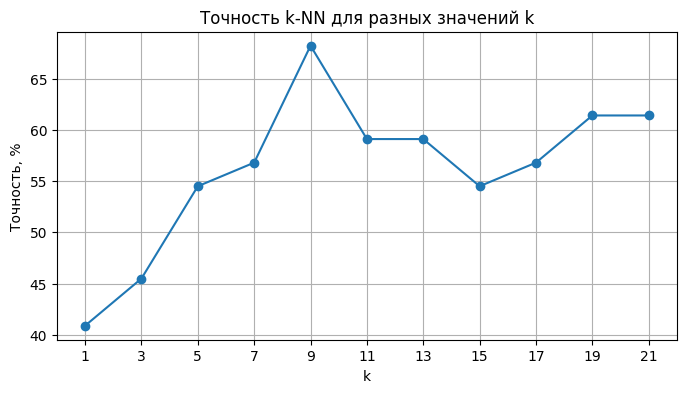

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(
    result_table["k"],
    result_table["accuracy_percent"],
    marker="o",
)
plt.xlabel("k")
plt.ylabel("Точность, %")
plt.title("Точность k-NN для разных значений k")
plt.xticks(result_table["k"])
plt.grid(True)
plt.show()

In [ ]:
best_row = result_table.loc[result_table["accuracy"].idxmax()]
best_k = int(best_row["k"])
best_accuracy = best_row["accuracy"]

majority_accuracy = (
    data[target].value_counts().max() / len(data)
)

print("Лучшее k:", best_k)
print(f"Точность k-NN: {best_accuracy:.1%}")
print(f"Базовая точность большинства: {majority_accuracy:.1%}")

Лучшее k: 9
Точность k-NN: 68.2%
Базовая точность большинства: 63.6%


### Вывод

Реализован метод k ближайших соседей. Для смешанных данных опроса использована простая метрика, которая одинаково учитывает категориальные и нормированные числовые признаки. Качество проверяется методом leave-one-out, после чего выбирается значение k с наибольшей точностью.